In [1]:
import cv2
import numpy as np
from shapely.geometry import Point, LineString, Polygon

In [2]:
def show_img(name='',img=None):
    cv2.imshow(name,img)
    cv2.waitKey()

In [3]:
img_path = r'./imgs/1.png'
img = cv2.imread(img_path)

# 转灰度图
imgGray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
# 高斯降噪
# imgBlur = cv2.GaussianBlur(imgGray,(15,7),1)

# 二值化，像素值为 【0 , 255】  2数字之一
# 当 maxval if pix_val>thresh 0
# cv2.THRESH_OTSU: 此时根据图像的直方图自动的选择阈值，手动设置的阈值失效！！！
# ret是返回的最佳阈值
# ret,imgBlur = cv2.threshold(src=imgGray, thresh=0, maxval=255,cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV)
ret,imgBlur = cv2.threshold(imgGray, 0, 255, cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV)
# 边缘检测
# image：要进行边缘检测的图像，一般是灰度图像。
# threshold1：第一次阈值。这是第一个阈值，如果一个像素的梯度大于它，就将其认为是边缘。
# threshold2：第二次阈值。这是第二个阈值，如果一个像素的梯度大于它并且与第一次阈值相连，则将其认为是边缘。 
# imgCanny = cv2.Canny(imgBlur,50,20)

# 获取卷积核
rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 3))
# 使用上述卷积核对图像上的白色区域做膨胀操作!!!!
dilation = cv2.dilate(imgBlur, rect_kernel, iterations = 2)

# 提取图像的外轮廓
contours,hierarchy = cv2.findContours(dilation,
                                      cv2.RETR_EXTERNAL,    # 只返回最外层的轮廓
                                      cv2.CHAIN_APPROX_NONE)
# 
img_out = cv2.drawContours(img.copy(),contours,-1,(0,255,0))

In [13]:
print('其中第一个轮廓的点集形状：',contours[0].shape)

其中第一个轮廓的点集形状： (1845, 1, 2)


-=-=-=-=-=-=-=-=
rect: ((292.5, 281.0), (24.0, 585.0), -90.0)
box_corrd: [[585 293]
 [  0 293]
 [  0 269]
 [585 269]]
该轮廓形状： (1245, 1, 2)
中心坐标： (292.5, 281.0)
宽    度： 24.0
长    度： 585.0
旋转角度： -90.0
-=-=-=-=-=-=-=-=
rect: ((451.5, 249.0), (903.0, 24.0), -0.0)
box_corrd: [[  0 261]
 [  0 237]
 [903 237]
 [903 261]]
该轮廓形状： (1848, 1, 2)
中心坐标： (451.5, 249.0)
宽    度： 903.0
长    度： 24.0
旋转角度： -0.0
-=-=-=-=-=-=-=-=
rect: ((451.5, 216.0), (903.0, 24.0), -0.0)
box_corrd: [[  0 228]
 [  0 204]
 [903 204]
 [903 228]]
该轮廓形状： (1848, 1, 2)
中心坐标： (451.5, 216.0)
宽    度： 903.0
长    度： 24.0
旋转角度： -0.0
-=-=-=-=-=-=-=-=
rect: ((451.5, 184.0), (24.0, 903.0), -90.0)
box_corrd: [[903 196]
 [  0 196]
 [  0 172]
 [903 172]]
该轮廓形状： (1865, 1, 2)
中心坐标： (451.5, 184.0)
宽    度： 24.0
长    度： 903.0
旋转角度： -90.0
-=-=-=-=-=-=-=-=
rect: ((451.5, 150.5), (903.0, 23.0), -0.0)
box_corrd: [[  0 162]
 [  0 139]
 [903 139]
 [903 162]]
该轮廓形状： (1848, 1, 2)
中心坐标： (451.5, 150.5)
宽    度： 903.0
长    度： 23.0
旋转角度： -0.0
-=-=-=-=-=-=-=-=

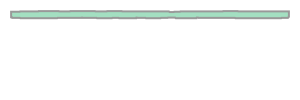

In [4]:
count = 0
collect_rect = None
for cnt in contours:
    count += 1
    # if count > 2:
    #     count=0
    #     break
    rect = cv2.minAreaRect(cnt) # cnt：轮廓的点集合， rect: (中心点坐标=(451.5, 20.5), 宽高=(903.0, 23.0), 旋转角度=-0.0)
    box = cv2.boxPoints(rect)   # 矩形的4个顶点的坐标
    cv2.line(img,(box[0][0],box[0][1]),(box[1][0],box[1][1]),(0,0,255),2)
    cv2.line(img,(box[2][0],box[2][1]),(box[1][0],box[1][1]),(0,0,255),2)
    cv2.line(img,(box[2][0],box[2][1]),(box[3][0],box[3][1]),(0,0,255),2)
    cv2.line(img,(box[0][0],box[0][1]),(box[3][0],box[3][1]),(0,0,255),2)
    print("-="*8)
    print('rect:',rect)
    print('box_corrd:',np.int0(box))
    print("该轮廓形状：", np.array(cnt).shape) # (组成该轮廓的点数=1845, 无效信息=1, 该点的xy坐标值=2)
    print("中心坐标：", rect[0])
    print("宽    度：", rect[1][0])
    print("长    度：", rect[1][1])
    print("旋转角度：", rect[2])
    collect_rect = cnt
Polygon(collect_rect.squeeze())
    

In [5]:
show_img(img=img)

In [6]:
np.array(contours).shape # (9,) 表示有9个轮廓

f:\my_softers\project_IDE\Anconda\envs\jp_layout_pytorch\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  """Entry point for launching an IPython kernel.


(9,)

In [7]:
np.array(contours[0]).shape # （轮廓点的个数=1845, 多余信息=1, x与y坐标值=2)

(1245, 1, 2)

In [8]:
contours = sorted(contours,key=lambda x: x[0][0][-1])
print('排序完成。。。。')

排序完成。。。。


第一个轮廓-点数量： 1845


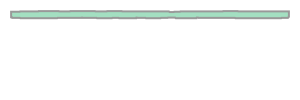

In [ ]:
print('第一个轮廓-点数量：',len(contours[0]))
Polygon(contours[0].squeeze())